In [68]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
import plotly.express as px

from scipy import stats
from scipy.stats import ttest_ind
import plotly.graph_objects as go


In [69]:
control_df  = pd.read_csv("questionnaire_control.csv")
eye_tracker_df  = pd.read_csv("questionnaire_treatment.csv")
eye_tracking_data = pd.read_csv("eye_tracking_data.csv")

In [70]:
combined_df = pd.concat([control_df, eye_tracker_df], axis=0)
combined_df

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,Gender,Race,Do you have any disabilities?,What disability do you have?,Do you have children?,Where do you live?,Would you like to share something more about your visit or your experience today?,Cubes Emotion Mean,Cubes Learning Mean,Group
0,2023-09-26 16:11:42,D05-P001,4.0,4.0,3.0,3.0,5.0,4.0,5,3,...,Feminino,Amarelo,Sim,Outra,Não,Cidade do Rio,NaN,4.0,3.0,Control
1,2023-09-26 16:33:48,D03-P010,8.0,4.0,8.0,5.0,4.0,8.0,8,1,...,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,Foi uma das experiencias mais incriveis que ja...,8.0,5.0,Control
2,2023-09-26 17:00:56,D05-P010,6.0,8.0,8.0,5.0,7.0,8.0,8,1,...,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,Admirei muito a visitacao. Super contente,6.0,5.0,Control
3,2023-09-26 19:36:08,D04-P017,8.0,8.0,1.0,8.0,7.0,2.0,8,5,...,Feminino,Branco,Não,NaN,Não,Outro País,NaN,8.0,8.0,Control
4,2023-09-27 17:33:42,D03-P032,6.0,8.0,8.0,8.0,8.0,8.0,8,1,...,Feminino,Branco,Não,NaN,Não,Outro País,Bellissima.,6.0,8.0,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,2023-10-01 23:02:26,D03-P066,6.0,8.0,5.0,6.0,5.0,6.0,8,1,...,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,NaN,6.0,6.0,Eye-Tracking
166,2023-10-01 23:15:33,D01-P063,6.0,8.0,7.0,6.0,8.0,7.0,7,4,...,Masculino,Preto,Não,NaN,Não,Outro Estado do Brasil,NaN,6.0,6.0,Eye-Tracking
167,2023-10-01 23:17:45,D05-P050,5.0,5.0,8.0,3.0,3.0,8.0,5,6,...,Feminino,Branco,Não,NaN,Não,Outro Estado do Brasil,NaN,5.0,3.0,Eye-Tracking
168,2023-10-01 23:44:36,D01-P064,8.0,8.0,8.0,8.0,8.0,8.0,8,3,...,Masculino,Branco,Não,NaN,Sim,Outro Estado do Brasil,NaN,8.0,8.0,Eye-Tracking


In [71]:
def plot_boxplot(df , group_col, value_col, xlabel, ylabel, ylim=(0, 10)):
    
    grouped = df.groupby(group_col)
    
    names, vals, xs = [], [], []

    for i, (name, subdf) in enumerate(grouped):
        names.append(name)
        vals.append(subdf[value_col].tolist())
        xs.append(np.random.normal(i + 1, 0.04, subdf.shape[0]))

    plt.boxplot(vals, labels=names)
    plt.ylim(*ylim)
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='gray', linestyle='dashed', alpha=0.5)

    ngroup = len(vals)
    clevels = np.linspace(0., 1., ngroup)

    for x, val, clevel in zip(xs, vals, clevels):
        # plt.scatter(x, val, color=cm.prism(clevel), alpha=0.4)
        plt.scatter(x, val, color=cm.winter(clevel), alpha=0.4)

    plt.show()

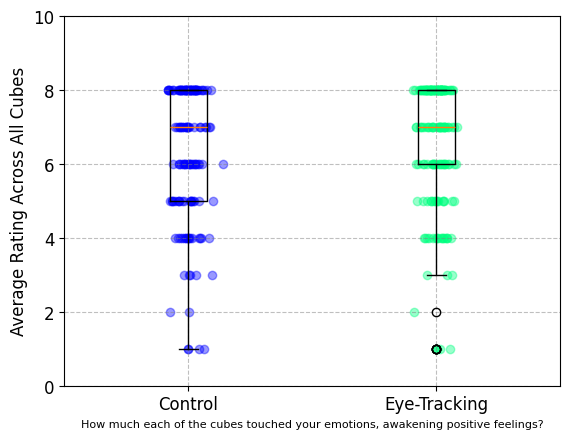

In [72]:
df = combined_df
group_col = 'Group'
value_col = 'Cubes Emotion Mean'
xlabel = 'How much each of the cubes touched your emotions, awakening positive feelings?'
ylabel = 'Average Rating Across All Cubes'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

In [73]:
control_values = control_df['Cubes Emotion Mean']
treatment_values = eye_tracker_df['Cubes Emotion Mean']

control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 6.2827586206896555, Treatment Mean: 6.570588235294117
Control Median: 7.0, Treatment Median: 7.0
Control Std: 1.8510636892363255, Treatment Std: 1.7602664893334303
t-test: t-statistic = -1.4068568375157924, p-value = 0.1605055546219527
Mann-Whitney U test: U-statistic = 11206.5, p-value = 0.1475087906694873


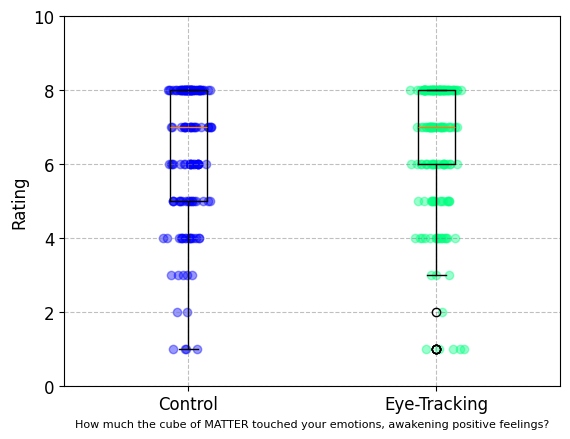

In [74]:
df = combined_df
group_col = 'Group'
value_col = 'Matter Emotions'
xlabel = 'How much the cube of MATTER touched your emotions, awakening positive feelings?'
ylabel = 'Rating'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

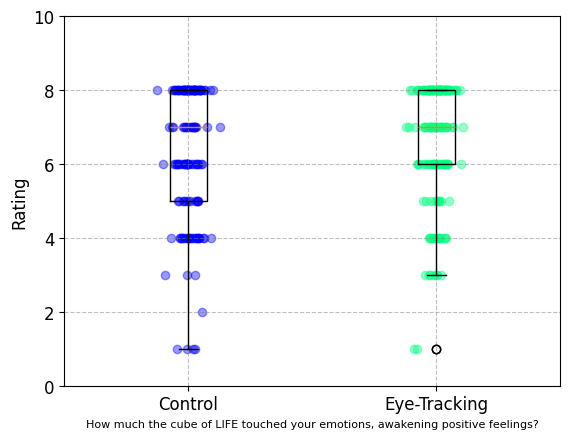

In [75]:
df = combined_df
group_col = 'Group'
value_col = 'Life Emotions'
xlabel = 'How much the cube of LIFE touched your emotions, awakening positive feelings?'
ylabel = 'Rating'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

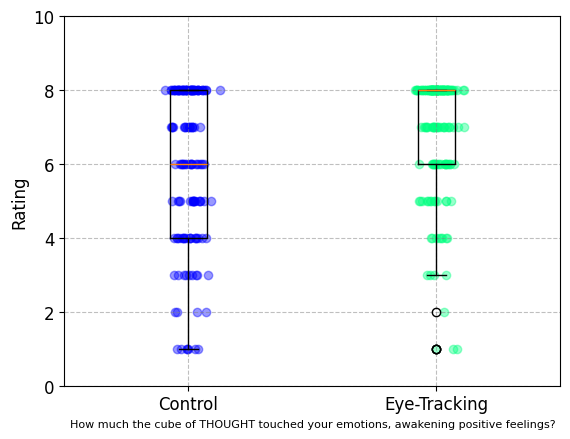

In [76]:
df = combined_df
group_col = 'Group'
value_col = 'Thought Emotions'
xlabel = 'How much the cube of THOUGHT touched your emotions, awakening positive feelings?'
ylabel = 'Rating'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

In [77]:
control_values = combined_df[combined_df['Group'] == 'Control']['Thought Emotions']
treatment_values = combined_df[combined_df['Group'] == 'Eye-Tracking']['Thought Emotions']

control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 5.9655172413793105, Treatment Mean: 6.923529411764706
Control Median: 6.0, Treatment Median: 8.0
Control Std: 2.11612129819134, Treatment Std: 1.6062118364732814
t-test: t-statistic = -4.463915928192118, p-value = 1.1903753769183402e-05
Mann-Whitney U test: U-statistic = 9112.0, p-value = 2.2317225056101027e-05


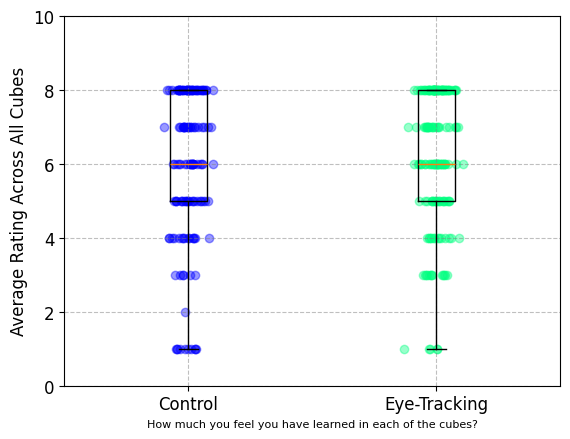

In [78]:
df = combined_df
group_col = 'Group'
value_col = 'Cubes Learning Mean'
xlabel = 'How much you feel you have learned in each of the cubes?'
ylabel = 'Average Rating Across All Cubes'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

In [79]:
control_values = control_df['Cubes Learning Mean']
treatment_values = eye_tracker_df['Cubes Learning Mean']

# Calculate basic statistics
control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 5.944827586206896, Treatment Mean: 6.182352941176471
Control Median: 6.0, Treatment Median: 6.0
Control Std: 2.0608092745085322, Treatment Std: 1.845107169356679
t-test: t-statistic = -1.0695954284361993, p-value = 0.28568498603249126
Mann-Whitney U test: U-statistic = 11674.0, p-value = 0.4070899002508577


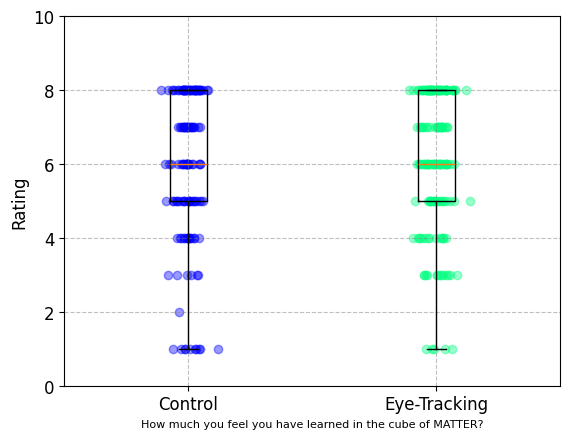

In [80]:
df = combined_df
group_col = 'Group'
value_col = 'Matter Learning'
xlabel = 'How much you feel you have learned in the cube of MATTER?'
ylabel = 'Rating'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

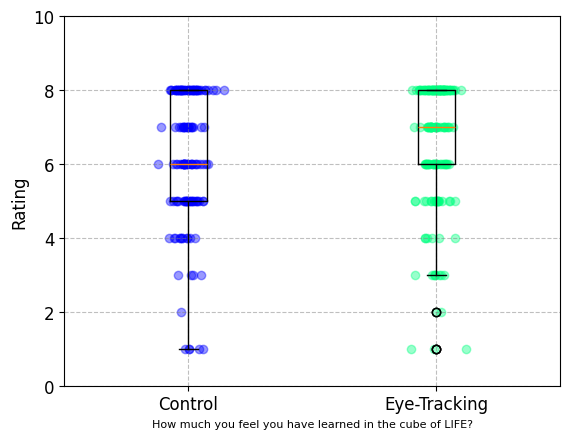

In [81]:
df = combined_df
group_col = 'Group'
value_col = 'Life Learning'
xlabel = 'How much you feel you have learned in the cube of LIFE?'
ylabel = 'Rating'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

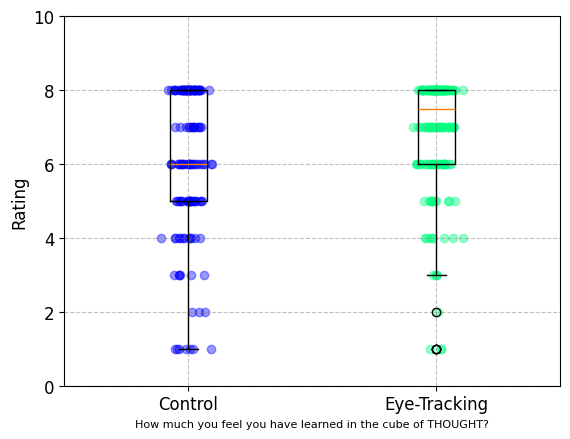

In [82]:
df = combined_df
group_col = 'Group'
value_col = 'Thought Learning'
xlabel = 'How much you feel you have learned in the cube of THOUGHT?'
ylabel = 'Rating'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

In [83]:
control_values = combined_df[combined_df['Group'] == 'Control']['Thought Learning']
treatment_values = combined_df[combined_df['Group'] == 'Eye-Tracking']['Thought Learning']

control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 6.089655172413793, Treatment Mean: 6.847058823529411
Control Median: 6.0, Treatment Median: 7.5
Control Std: 2.006646045641937, Treatment Std: 1.5764981217496787
t-test: t-statistic = -3.6787313055902406, p-value = 0.0002826057040372506
Mann-Whitney U test: U-statistic = 9692.5, p-value = 0.0005870090694799704


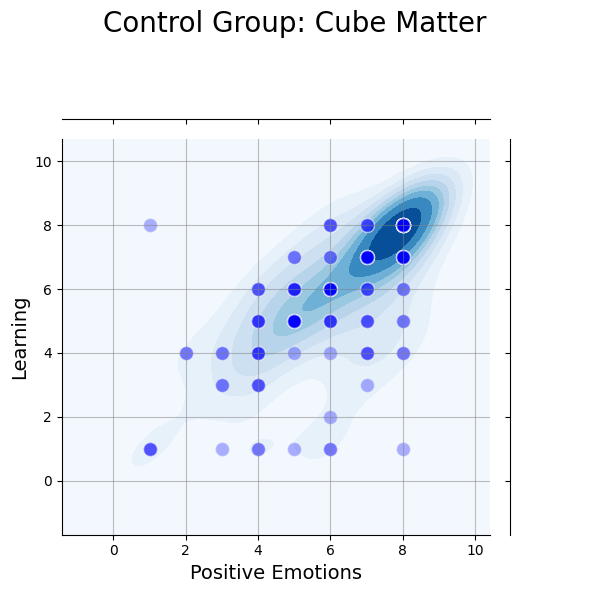

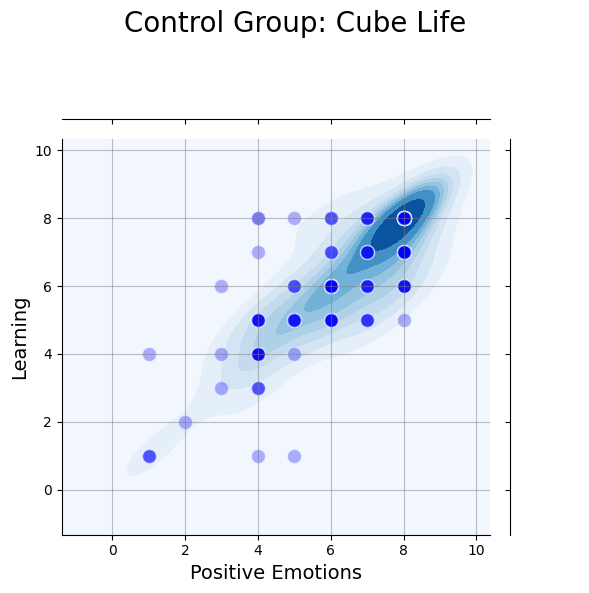

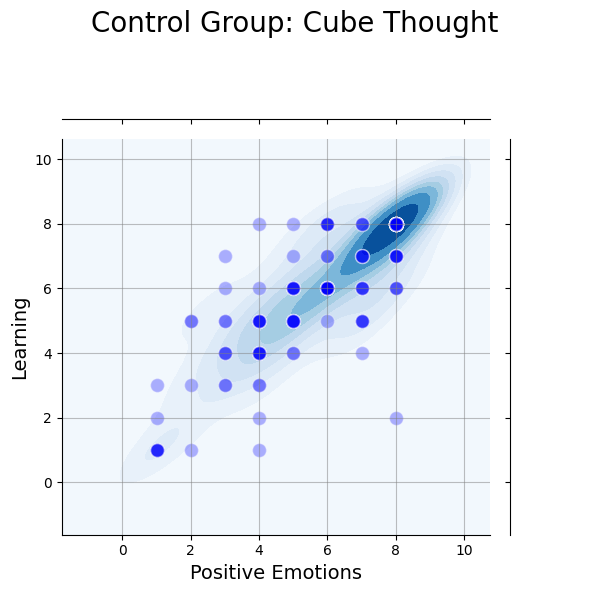

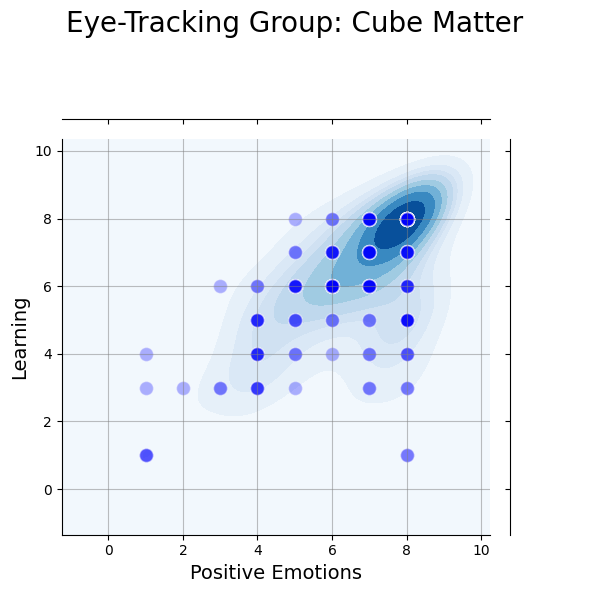

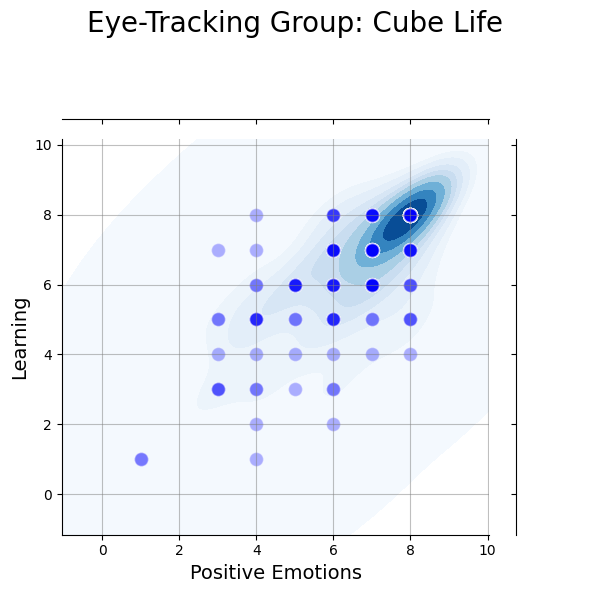

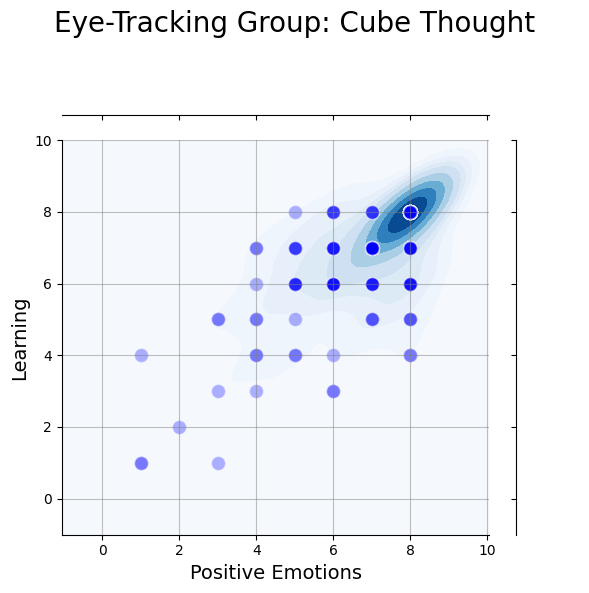

In [84]:
title_mapping = {
    'Matter Emotions': 'Cube Matter',
    'Life Emotions': 'Cube Life',
    'Thought Emotions': 'Cube Thought'
}

def plot_group_data(group_df, group_name):
    pairs = [
        ('Matter Emotions', 'Matter Learning'),
        ('Life Emotions', 'Life Learning'),
        ('Thought Emotions', 'Thought Learning')
    ]

    for emotion_col, learning_col in pairs:
        g = sns.JointGrid(data=group_df, x=emotion_col, y=learning_col)

        g.plot_joint(sns.kdeplot, fill=True, cmap="Blues", alpha=1, levels=10, thresh=0)
        
        g.ax_joint.scatter(group_df[emotion_col], group_df[learning_col], color='blue', edgecolor='w', s=100, alpha=0.3)
        
        g.ax_joint.set_xlabel(emotion_col, fontsize=20)
        g.ax_joint.set_ylabel(learning_col, fontsize=20)

        # Set font size for tick labels
        # g.ax_joint.tick_params(axis='both', labelsize=16)

        ticks = [0, 2, 4, 6, 8, 10]
        g.ax_joint.set_xticks(ticks)
        g.ax_joint.set_yticks(ticks)


        g.ax_joint.set_xlabel('Positive Emotions', fontsize=14)
        g.ax_joint.set_ylabel('Learning', fontsize=14)

        title = f'{group_name} Group: {title_mapping[emotion_col]}'
        g.fig.suptitle(title, fontsize=20)
        g.fig.tight_layout()
        g.ax_joint.grid(color='gray', linestyle='solid', alpha=0.5)
        plt.show()

plot_group_data(control_df, 'Control')
plot_group_data(eye_tracker_df, 'Eye-Tracking')



In [85]:
eye_tracker_df = pd.merge(eye_tracker_df, eye_tracking_data, on='ID', how='inner')
eye_tracker_df = eye_tracker_df[eye_tracker_df['has_corruption'] == False]

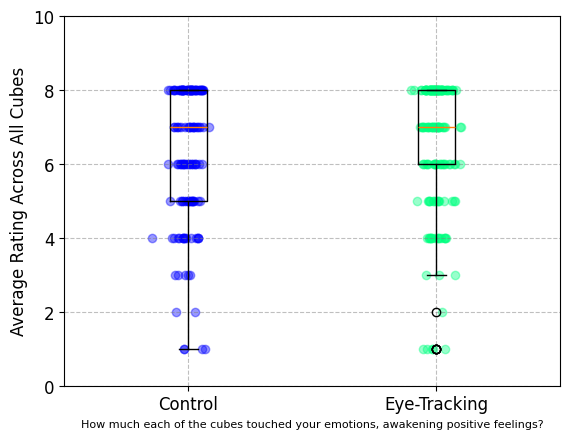

In [86]:
df = combined_df
group_col = 'Group'
value_col = 'Cubes Emotion Mean'
xlabel = 'How much each of the cubes touched your emotions, awakening positive feelings?'
ylabel = 'Average Rating Across All Cubes'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10))

In [87]:
eye_tracker_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136 entries, 0 to 169
Data columns (total 88 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Start time                                                                         136 non-null    object 
 1   ID                                                                                 136 non-null    object 
 2   Matter Emotions                                                                    136 non-null    float64
 3   Life Emotions                                                                      136 non-null    float64
 4   Thought Emotions                                                                   136 non-null    float64
 5   Matter Learning                                                                    136 non-null    float64
 6  

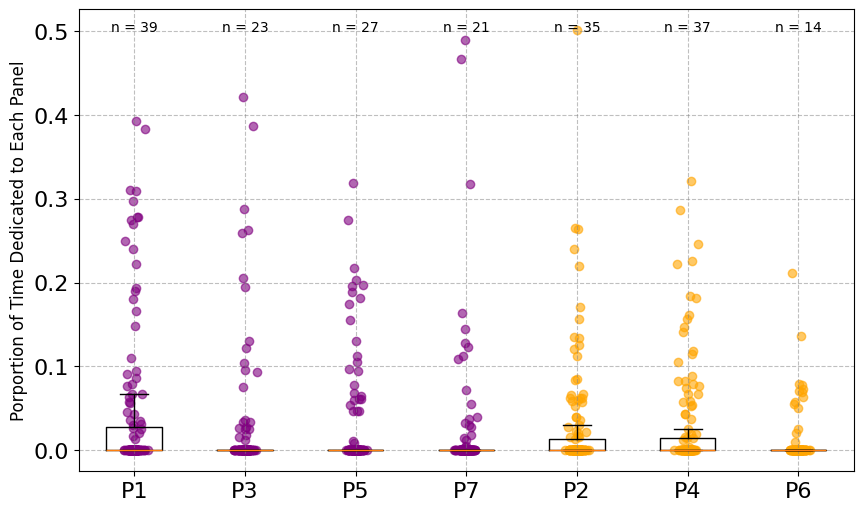

In [88]:
def plot_boxplot(df, columns, xlabel, ylabel, ylim=None):
    vals = [df[col].dropna().tolist() for col in columns]  # Handle NaNs
    xs = [np.random.normal(i + 1, 0.04, len(vals[i])) for i in range(len(vals))]

    plt.figure(figsize=(10, 6))
    plt.boxplot(vals, labels=["P1", "P3", "P5", "P7", "P2", "P4", "P6"], showfliers=False)
    
    
    if ylim:
        plt.ylim(*ylim)

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(color="gray", linestyle="dashed", alpha=0.5)

    scatter_colors = ["Purple", "Purple", "Purple", "Purple", "Orange", "Orange", "Orange"]

    for x, val, color in zip(xs, vals, scatter_colors):
        plt.scatter(x, val, color=color, alpha=0.6)
        
    for i, val in enumerate(vals):
        n_non_zero = sum(v != 0 for v in val)  # Count non-zero values
        plt.text(i + 1, plt.ylim()[1] * 0.95, f"n = {n_non_zero}", ha='center', fontsize=10, color='black')


    plt.show()

plot_boxplot(
eye_tracker_df,
columns=["p1_percentage", "p3_percentage", "p5_percentage", "p7_percentage", "p2_percentage", "p4_percentage", "p6_percentage"],
xlabel="",
ylabel="Porportion of Time Dedicated to Each Panel",
ylim= None,
)


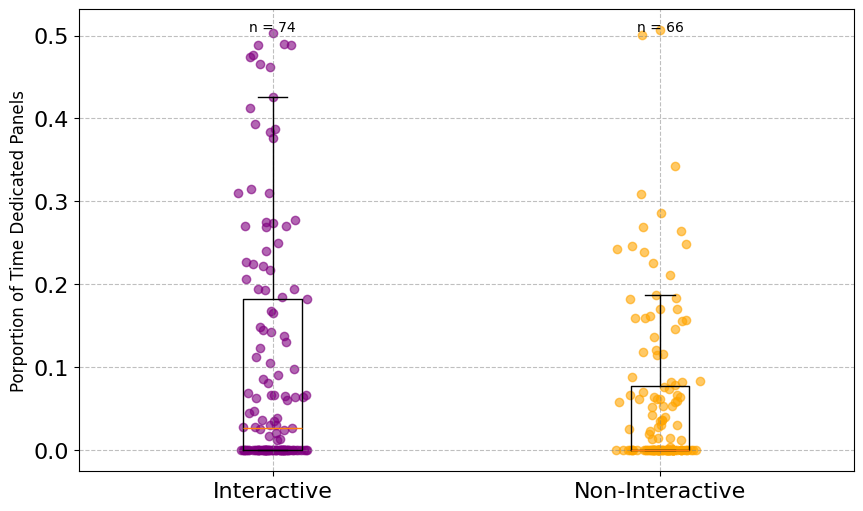

In [89]:
def plot_boxplot(df, columns, xlabel, ylabel, ylim=None):
    vals = [df[col].dropna().tolist() for col in columns]  # Handle NaNs
    xs = [np.random.normal(i + 1, 0.04, len(vals[i])) for i in range(len(vals))]

    plt.figure(figsize=(10, 6))
    plt.boxplot(vals, labels=["Interactive", "Non-Interactive"], showfliers=False)
    
    
    if ylim:
        plt.ylim(*ylim)

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(color="gray", linestyle="dashed", alpha=0.5)

    scatter_colors = ["Purple", "Orange"]

    for x, val, color in zip(xs, vals, scatter_colors):
        plt.scatter(x, val, color=color, alpha=0.6)
        
    for i, val in enumerate(vals):
        n_non_zero = sum(v != 0 for v in val)  # Count non-zero values
        plt.text(i + 1, plt.ylim()[1] * 0.95, f"n = {n_non_zero}", ha='center', fontsize=10, color='black')


    plt.show()

plot_boxplot(
eye_tracker_df,
columns=["interactive_panel_percentage", "noninteractive_panel_percentage"],
xlabel="",
ylabel="Porportion of Time Dedicated Panels",
ylim= None,
)


In [90]:
noninteractive = eye_tracker_df['noninteractive_panel_percentage']
interactive = eye_tracker_df['interactive_panel_percentage']

stat, p = ttest_ind(noninteractive, interactive, equal_var=False)
print(f"Independent t-Test: Statistic={stat}, p={p}")


Independent t-Test: Statistic=-2.9041763250096886, p=0.00403306135087968


In [91]:
control_values = control_df['Cubes Emotion Mean']
treatment_values = eye_tracker_df['Cubes Emotion Mean']

control_mean = control_values.mean()
treatment_mean = treatment_values.mean()
control_median = control_values.median()
treatment_median = treatment_values.median()
control_std = control_values.std()
treatment_std = treatment_values.std()

print(f"Control Mean: {control_mean}, Treatment Mean: {treatment_mean}")
print(f"Control Median: {control_median}, Treatment Median: {treatment_median}")
print(f"Control Std: {control_std}, Treatment Std: {treatment_std}")

# Perform a t-test for independent samples
t_stat, p_value = stats.ttest_ind(control_values, treatment_values, equal_var=False)  # Welch’s t-test
print(f"t-test: t-statistic = {t_stat}, p-value = {p_value}")

# Perform a Mann-Whitney U test
u_stat, p_value_mwu = stats.mannwhitneyu(control_values, treatment_values, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat}, p-value = {p_value_mwu}")


Control Mean: 6.2827586206896555, Treatment Mean: 6.514705882352941
Control Median: 7.0, Treatment Median: 7.0
Control Std: 1.8510636892363255, Treatment Std: 1.8776868910982414
t-test: t-statistic = -1.041947529224096, p-value = 0.2983435947906649
Mann-Whitney U test: U-statistic = 8981.5, p-value = 0.17722682862316286


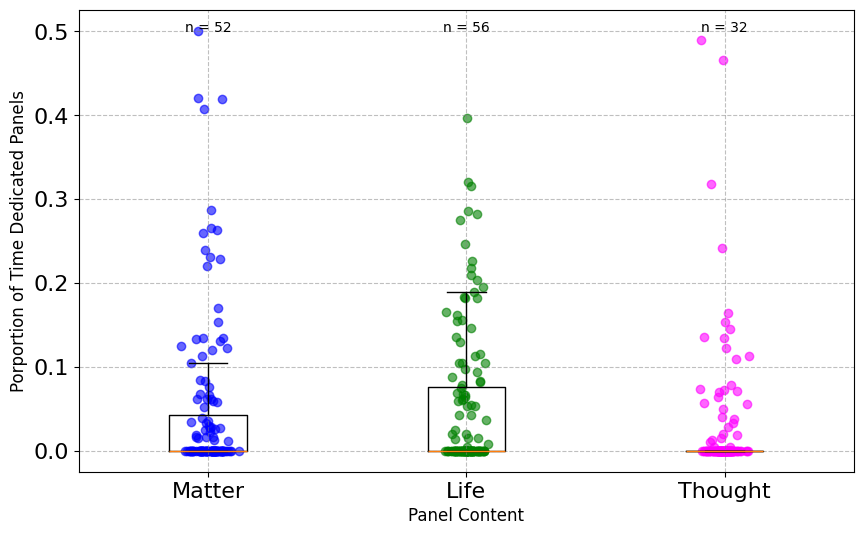

In [92]:
def plot_boxplot(df, columns, xlabel, ylabel, ylim=None):
    vals = [df[col].dropna().tolist() for col in columns]  # Handle NaNs
    xs = [np.random.normal(i + 1, 0.04, len(vals[i])) for i in range(len(vals))]

    plt.figure(figsize=(10, 6))
    plt.boxplot(vals, labels=["Matter", "Life", "Thought"], showfliers=False)
    
    
    if ylim:
        plt.ylim(*ylim)

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(color="gray", linestyle="dashed", alpha=0.5)

    scatter_colors = ["Blue", "Green","Fuchsia"]

    for x, val, color in zip(xs, vals, scatter_colors):
        plt.scatter(x, val, color=color, alpha=0.6)
        
    for i, val in enumerate(vals):
        n_non_zero = sum(v != 0 for v in val)  # Count non-zero values
        plt.text(i + 1, plt.ylim()[1] * 0.95, f"n = {n_non_zero}", ha='center', fontsize=10, color='black')


    plt.show()

plot_boxplot(
eye_tracker_df,
columns=["matter_panel_percentage", "life_panel_percentage", "thought_panel_percentage"],
xlabel="Panel Content",
ylabel="Porportion of Time Dedicated Panels",
ylim= None,
)


In [93]:
panel_columns = [f'p{i}_duration' for i in range(1, 8)]
total_time_per_panel = eye_tracker_df[panel_columns].sum()
total_time_per_panel


p1_duration    132.531568
p2_duration     80.425491
p3_duration     89.312981
p4_duration    100.791230
p5_duration     92.883401
p6_duration     27.811006
p7_duration     64.056550
dtype: float64

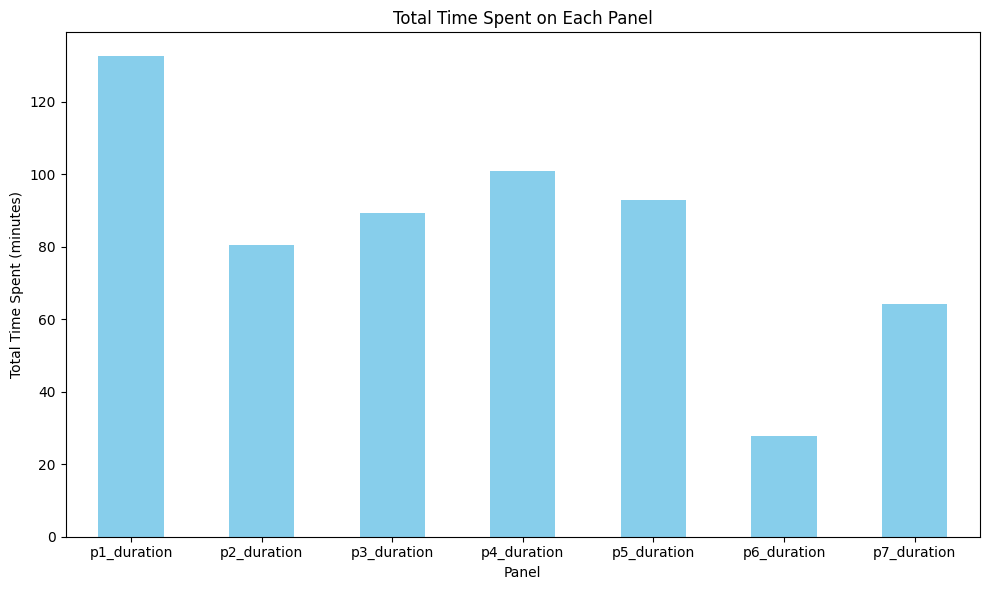

In [94]:
plt.figure(figsize=(10, 6))
total_time_per_panel.plot(kind='bar', color='skyblue')

plt.title('Total Time Spent on Each Panel')
plt.xlabel('Panel')
plt.ylabel('Total Time Spent (minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Who engages with panels more frequently? (more frequently ?= more pickups)
# Who are heavy users and who are low users?

In [95]:
eye_tracker_df['Age group 2'] = eye_tracker_df['Age group'].apply(
    lambda x: 'Up to 30 years' if x in ['Até 18 anos', '19-30 anos'] else '31 years and above'
)

eye_tracker_df[['Age group', 'Age group 2']]


,Age group,Age group 2
0,31-59 anos,31 years and above
1,19-30 anos,Up to 30 years
2,31-59 anos,31 years and above
3,19-30 anos,Up to 30 years
4,31-59 anos,31 years and above
...,...,...
165,19-30 anos,Up to 30 years
166,19-30 anos,Up to 30 years
167,19-30 anos,Up to 30 years
168,19-30 anos,Up to 30 years


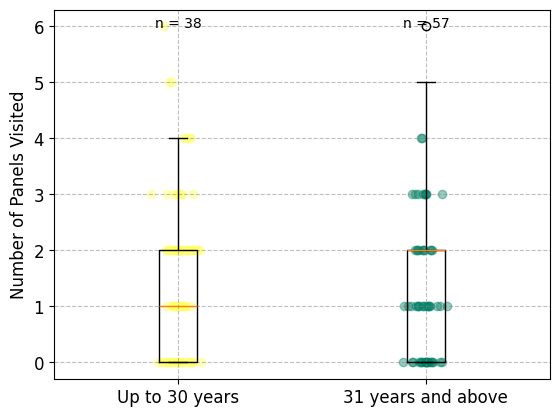

In [96]:
def plot_boxplot(df , group_col, value_col, xlabel, ylabel, ylim=(0, 10)):
    
    grouped = df.groupby(group_col)
    
    names, vals, xs = [], [], []

    for i, (name, subdf) in enumerate(grouped):
        names.append(name)
        vals.append(subdf[value_col].tolist())
        xs.append(np.random.normal(i + 1, 0.04, subdf.shape[0]))

    names.reverse()
    vals.reverse()
    xs.reverse()

    plt.boxplot(vals, labels=names)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='gray', linestyle='dashed', alpha=0.5)

    ngroup = len(vals)
    clevels = np.linspace(0., 1., ngroup)

    for x, val, clevel in zip(xs, vals, clevels):
        # plt.scatter(x, val, color=cm.prism(clevel), alpha=0.4)
        plt.scatter(x, val, color=cm.summer(clevel), alpha=0.4)

    for i, val in enumerate(vals):
        n_non_zero = sum(v != 0 for v in val)  # Count non-zero values
        plt.text(i + 1, plt.ylim()[1] * 0.95, f"n = {n_non_zero}", ha='center', fontsize=10, color='black')

    plt.show()



df = eye_tracker_df
group_col = 'Age group 2'
value_col = 'number_of_panels'
xlabel = ''
ylabel = 'Number of Panels Visited'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=None)

In [97]:
younger_group = eye_tracker_df[eye_tracker_df['Age group 2'] == 'Up to 30 years']['number_of_panels']
older_group = eye_tracker_df[eye_tracker_df['Age group 2'] == '31 years and above']['number_of_panels']

stat, p = ttest_ind(younger_group, older_group, equal_var=False)  # Welch's t-test (unequal variances)
print(f"t-Statistic: {stat}, p-value: {p}")

t-Statistic: -1.3889798330206786, p-value: 0.16722096763438468


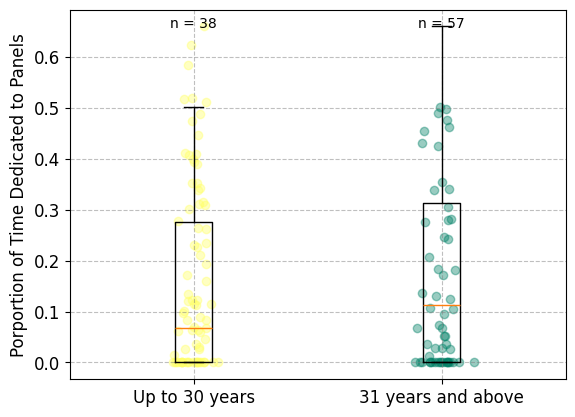

In [98]:
df = eye_tracker_df
group_col = 'Age group 2'
value_col = 'overall_panel_percentage'
xlabel = ''
ylabel = 'Porportion of Time Dedicated to Panels'


plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=None)

In [99]:
younger_group = eye_tracker_df[eye_tracker_df['Age group 2'] == 'Up to 30 years']['overall_panel_percentage']
older_group = eye_tracker_df[eye_tracker_df['Age group 2'] == '31 years and above']['overall_panel_percentage']

stat, p = ttest_ind(younger_group, older_group, equal_var=False)  
print(f"t-Statistic: {stat}, p-value: {p}")

t-Statistic: -0.9978448811522492, p-value: 0.32025115994301057


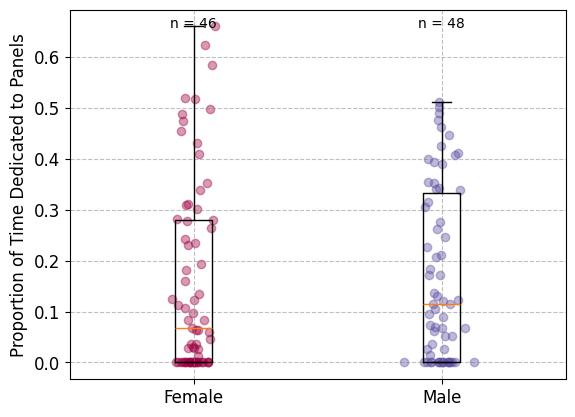

In [100]:
def plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10)):
    grouped = df.groupby(group_col)
    
    names, vals, xs = [], [], []

    for i, (name, subdf) in enumerate(grouped):
        names.append(name)
        vals.append(subdf[value_col].tolist())
        xs.append(np.random.normal(i + 1, 0.04, subdf.shape[0]))

    # Remove the third element from the lists if it exists
    if len(names) > 2:
        names.pop(2)
        vals.pop(2)
        xs.pop(2)

    plt.boxplot(vals, labels=["Female", "Male"])
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='gray', linestyle='dashed', alpha=0.5)

    ngroup = len(vals)
    clevels = np.linspace(0., 1., ngroup)

    for x, val, clevel in zip(xs, vals, clevels):
        plt.scatter(x, val, color=cm.Spectral(clevel), alpha=0.4)

    for i, val in enumerate(vals):
        n_non_zero = sum(v != 0 for v in val)  # Count non-zero values
        plt.text(i + 1, plt.ylim()[1] * 0.95, f"n = {n_non_zero}", ha='center', fontsize=10, color='black')

    plt.show()

df = eye_tracker_df
group_col = 'Gender'
value_col = 'overall_panel_percentage'
xlabel = ''
ylabel = 'Proportion of Time Dedicated to Panels'

plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=None)

In [101]:
female_group = eye_tracker_df[eye_tracker_df['Gender'] == 'Feminino']['overall_panel_percentage']
male_group = eye_tracker_df[eye_tracker_df['Gender'] == 'Masculino']['overall_panel_percentage']

stat, p = ttest_ind(younger_group, older_group, equal_var=False)  # Welch's t-test (unequal variances)
print(f"t-Statistic: {stat}, p-value: {p}")

t-Statistic: -0.9978448811522492, p-value: 0.32025115994301057


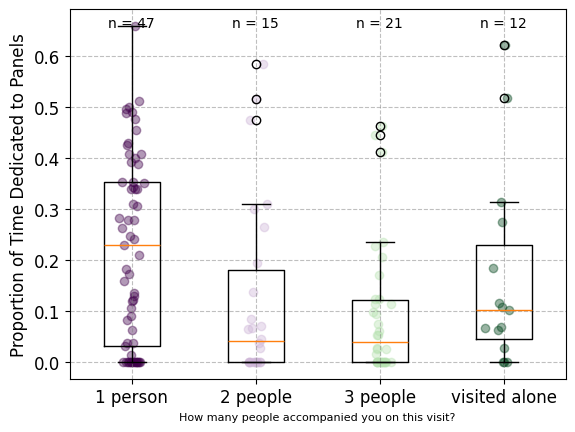

In [102]:
def plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10)):
    grouped = df.groupby(group_col)
    
    names, vals, xs = [], [], []

    for i, (name, subdf) in enumerate(grouped):
        names.append(name)
        vals.append(subdf[value_col].tolist())
        xs.append(np.random.normal(i + 1, 0.04, subdf.shape[0]))


    plt.boxplot(vals, labels=['1 person', '2 people', '3 people', 'visited alone'])
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='gray', linestyle='dashed', alpha=0.5)

    ngroup = len(vals)
    clevels = np.linspace(0., 1., ngroup)

    for x, val, clevel in zip(xs, vals, clevels):
        plt.scatter(x, val, color=cm.PRGn(clevel), alpha=0.4)

    for i, val in enumerate(vals):
        n_non_zero = sum(v != 0 for v in val)  # Count non-zero values
        plt.text(i + 1, plt.ylim()[1] * 0.95, f"n = {n_non_zero}", ha='center', fontsize=10, color='black')

    plt.show()

df = eye_tracker_df
group_col = 'How many people accompanied you on this visit?'
value_col = 'overall_panel_percentage'
xlabel = 'How many people accompanied you on this visit?'
ylabel = 'Proportion of Time Dedicated to Panels'

plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=None)

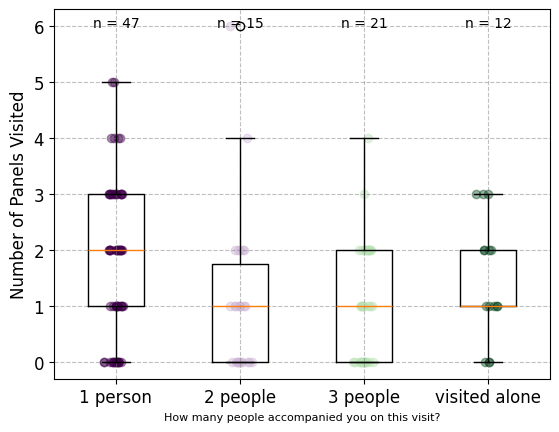

In [103]:
df = eye_tracker_df
group_col = 'How many people accompanied you on this visit?'
value_col = 'number_of_panels'
xlabel = 'How many people accompanied you on this visit?'
ylabel = 'Number of Panels Visited'

plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=None)

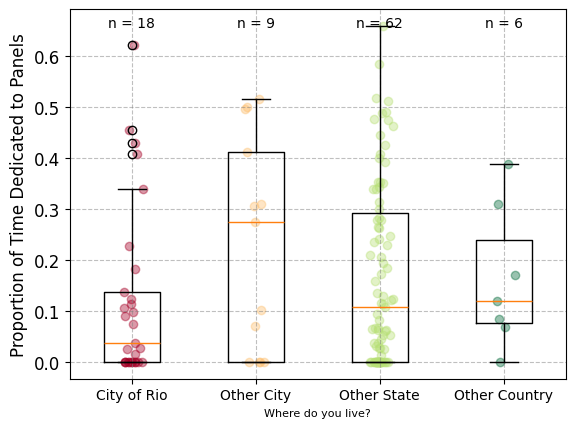

In [121]:
def plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=(0, 10)):
    grouped = df.groupby(group_col)
    
    names, vals, xs = [], [], []

    for i, (name, subdf) in enumerate(grouped):
        names.append(name)
        vals.append(subdf[value_col].tolist())
        xs.append(np.random.normal(i + 1, 0.04, subdf.shape[0]))


    plt.boxplot(vals, labels=['City of Rio', 'Other City', 'Other State', 'Other Country'])
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=12)
    plt.grid(color='gray', linestyle='dashed', alpha=0.5)

    ngroup = len(vals)
    clevels = np.linspace(0., 1., ngroup)

    for x, val, clevel in zip(xs, vals, clevels):
        plt.scatter(x, val, color=cm.RdYlGn(clevel), alpha=0.4)

    for i, val in enumerate(vals):
        n_non_zero = sum(v != 0 for v in val)  # Count non-zero values
        plt.text(i + 1, plt.ylim()[1] * 0.95, f"n = {n_non_zero}", ha='center', fontsize=10, color='black')

    plt.show()

df = eye_tracker_df
group_col = 'Where do you live?'
value_col = 'overall_panel_percentage'
xlabel = 'Where do you live?'
ylabel = 'Proportion of Time Dedicated to Panels'

plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=None)

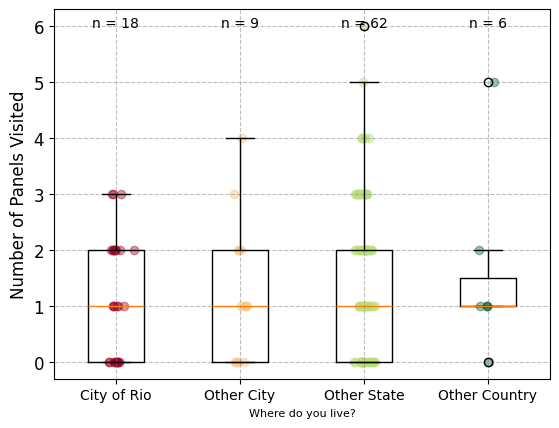

In [122]:
df = eye_tracker_df
group_col = 'Where do you live?'
value_col = 'number_of_panels'
xlabel = 'Where do you live?'
ylabel = 'Number of Panels Visited'

plot_boxplot(df, group_col, value_col, xlabel, ylabel, ylim=None)

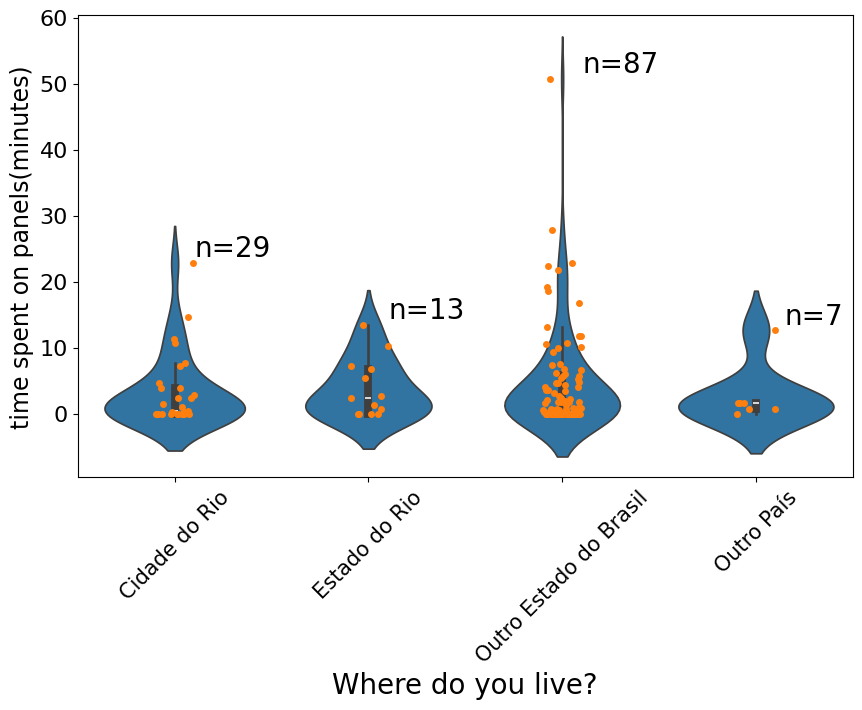

In [106]:
answer_order = ['Cidade do Rio','Estado do Rio','Outro Estado do Brasil','Outro País']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Where do you live?', y='overall_panel_duration', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Where do you live?', y='overall_panel_duration', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Where do you live?'] == group]['overall_panel_duration']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Where do you live?', fontsize=20)
plt.ylabel( 'time spent on panels(minutes)', fontsize=17)
plt.xticks(fontsize=15, rotation=45)
current_yticks = plt.yticks()[0]
plt.yticks(fontsize=16)

plt.show()


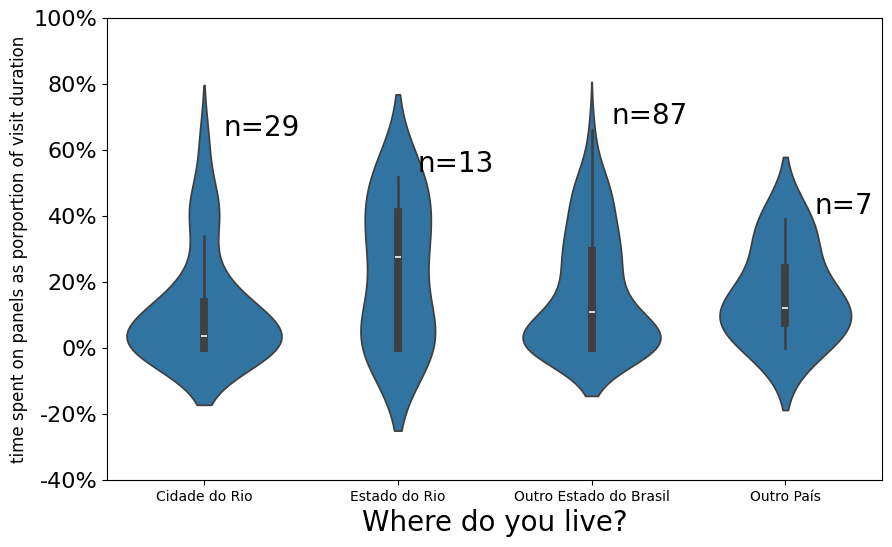

In [107]:
answer_order = ['Cidade do Rio','Estado do Rio','Outro Estado do Brasil','Outro País']
plt.figure(figsize=(10, 6))

sns.violinplot(x='Where do you live?', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order)
sns.stripplot(x='Where do you live?', y='overall_panel_percentage', data=eye_tracker_df, order=answer_order, dodge=True, jitter=True, alpha=0)

for i, group in enumerate(answer_order):
    x = i
    y = eye_tracker_df[eye_tracker_df['Where do you live?'] == group]['overall_panel_percentage']
    plt.text(x + 0.3, max(y), f'n={len(y)}', ha='center', va='bottom', fontsize=20)

plt.xlabel('Where do you live?', fontsize=20)
plt.ylabel( 'time spent on panels as porportion of visit duration', fontsize=12)
plt.ylim([-0.25, 1])
plt.xticks(fontsize=10)
current_yticks = plt.yticks()[0]
plt.yticks(ticks=current_yticks, labels=[f'{int(tick*100)}%' for tick in current_yticks], fontsize=16)

plt.show()


In [108]:
eye_tracker_df['Where do you live?'].unique()

array(['Outro Estado do Brasil', 'Cidade do Rio', 'Outro País',
       'Estado do Rio'], dtype=object)

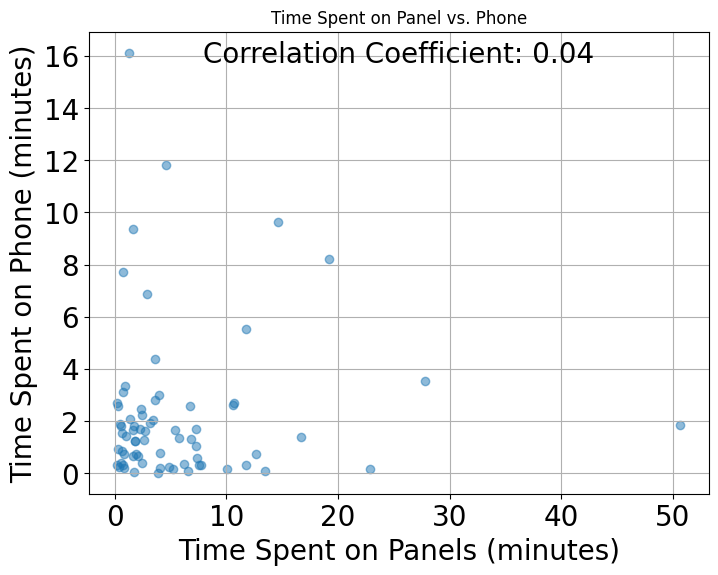

In [109]:
et_df_copy = eye_tracker_df
# et_df_copy = et_df_copy[et_df_copy['has_corruption'] == False]
# et_df_copy['overall_panel_duration_minutes'] = et_df_copy['overall_panel_duration'].dt.total_seconds() / 60
# et_df_copy['phone_duration_minutes'] = et_df_copy['phone_duration'].dt.total_seconds() / 60

et_df_copy = et_df_copy[(et_df_copy['overall_panel_duration'] != 0) & (et_df_copy['phone_duration'] != 0)]

plt.figure(figsize=(8, 6))
plt.scatter(et_df_copy['overall_panel_duration'], et_df_copy['phone_duration'], alpha=0.5)
plt.title('Time Spent on Panel vs. Phone')
plt.xlabel('Time Spent on Panels (minutes)', fontsize = 20)
plt.ylabel('Time Spent on Phone (minutes)', fontsize = 20)

correlation_coefficient = np.corrcoef(et_df_copy['overall_panel_duration'], et_df_copy['phone_duration'])[0, 1]

plt.text(0.5, 0.95, f'Correlation Coefficient: {correlation_coefficient:.2f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.show()

C:\Users\aslan\AppData\Local\Temp\ipykernel_15520\3364009872.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  et_df_copy['phone_duration_percentage'] = (et_df_copy['phone_duration'] / et_df_copy['overall_duration']) * 100
C:\Users\aslan\AppData\Local\Temp\ipykernel_15520\3364009872.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  et_df_copy['overall_panel_duration_minutes_percentage'] = (et_df_copy['overall_panel_duration'] / et_df_copy['overall_duration']) * 100


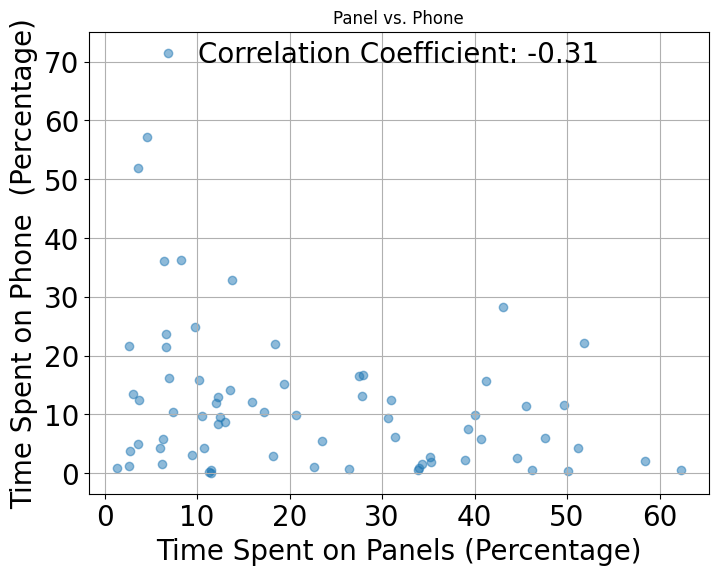

In [110]:
et_df_copy = eye_tracker_df

et_df_copy = et_df_copy[(et_df_copy['overall_panel_duration'] != 0) & (et_df_copy['phone_duration'] != 0)]

et_df_copy['phone_duration_percentage'] = (et_df_copy['phone_duration'] / et_df_copy['overall_duration']) * 100
et_df_copy['overall_panel_duration_minutes_percentage'] = (et_df_copy['overall_panel_duration'] / et_df_copy['overall_duration']) * 100

plt.figure(figsize=(8, 6))
plt.scatter(et_df_copy['overall_panel_duration_minutes_percentage'], et_df_copy['phone_duration_percentage'], alpha=0.5)
plt.title('Panel vs. Phone')
plt.xlabel('Time Spent on Panels (Percentage)', fontsize=20)
plt.ylabel('Time Spent on Phone  (Percentage)', fontsize=20)

correlation_coefficient = np.corrcoef(et_df_copy['overall_panel_duration_minutes_percentage'], et_df_copy['phone_duration_percentage'])[0, 1]

plt.text(0.5, 0.95, f'Correlation Coefficient: {correlation_coefficient:.2f}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.show()


In [111]:
eye_tracker_df

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,p7_percentage,matter_panel_percentage,life_panel_percentage,thought_panel_percentage,overall_panel_percentage,interactive_panel_duration,noninteractive_panel_duration,interactive_panel_percentage,noninteractive_panel_percentage,Age group 2
0,2023-09-26 16:34:00,D03-P011,8.0,3.0,6.0,5.0,7.0,7.0,8,3,...,0.000000,0.000000,0.135205,0.000000,0.135205,0.816848,1.524076,0.047179,0.088026,31 years and above
1,2023-09-26 16:59:30,D03-P012,7.0,7.0,7.0,7.0,7.0,7.0,8,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Up to 30 years
2,2023-09-26 17:19:10,D05-P013,4.0,6.0,8.0,3.0,5.0,7.0,5,2,...,0.000000,0.000000,0.053891,0.000000,0.089199,0.603050,0.920437,0.035308,0.053891,31 years and above
3,2023-09-26 17:27:36,D05-P014,7.0,6.0,8.0,6.0,7.0,8.0,8,4,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Up to 30 years
4,2023-09-26 17:26:13,D03-P013,8.0,8.0,8.0,8.0,8.0,5.0,8,1,...,0.000000,0.039131,0.025188,0.000000,0.064319,0.000000,1.668494,0.000000,0.064319,31 years and above
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,2023-10-01 23:02:26,D03-P066,6.0,8.0,5.0,6.0,5.0,6.0,8,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Up to 30 years
166,2023-10-01 23:15:33,D01-P063,6.0,8.0,7.0,6.0,8.0,7.0,7,4,...,0.027815,0.067148,0.000000,0.027815,0.094963,0.606730,1.464672,0.027815,0.067148,Up to 30 years
167,2023-10-01 23:17:45,D05-P050,5.0,5.0,8.0,3.0,3.0,8.0,5,6,...,0.000000,0.025910,0.000000,0.000000,0.025910,0.733121,0.000000,0.025910,0.000000,Up to 30 years
168,2023-10-01 23:44:36,D01-P064,8.0,8.0,8.0,8.0,8.0,8.0,8,3,...,0.032536,0.029944,0.000000,0.032536,0.172592,2.617844,0.549530,0.142647,0.029944,Up to 30 years


In [112]:
eye_tracker_df

,Start time,ID,Matter Emotions,Life Emotions,Thought Emotions,Matter Learning,Life Learning,Thought Learning,Admiration,Confusion,...,p7_percentage,matter_panel_percentage,life_panel_percentage,thought_panel_percentage,overall_panel_percentage,interactive_panel_duration,noninteractive_panel_duration,interactive_panel_percentage,noninteractive_panel_percentage,Age group 2
0,2023-09-26 16:34:00,D03-P011,8.0,3.0,6.0,5.0,7.0,7.0,8,3,...,0.000000,0.000000,0.135205,0.000000,0.135205,0.816848,1.524076,0.047179,0.088026,31 years and above
1,2023-09-26 16:59:30,D03-P012,7.0,7.0,7.0,7.0,7.0,7.0,8,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Up to 30 years
2,2023-09-26 17:19:10,D05-P013,4.0,6.0,8.0,3.0,5.0,7.0,5,2,...,0.000000,0.000000,0.053891,0.000000,0.089199,0.603050,0.920437,0.035308,0.053891,31 years and above
3,2023-09-26 17:27:36,D05-P014,7.0,6.0,8.0,6.0,7.0,8.0,8,4,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Up to 30 years
4,2023-09-26 17:26:13,D03-P013,8.0,8.0,8.0,8.0,8.0,5.0,8,1,...,0.000000,0.039131,0.025188,0.000000,0.064319,0.000000,1.668494,0.000000,0.064319,31 years and above
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,2023-10-01 23:02:26,D03-P066,6.0,8.0,5.0,6.0,5.0,6.0,8,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Up to 30 years
166,2023-10-01 23:15:33,D01-P063,6.0,8.0,7.0,6.0,8.0,7.0,7,4,...,0.027815,0.067148,0.000000,0.027815,0.094963,0.606730,1.464672,0.027815,0.067148,Up to 30 years
167,2023-10-01 23:17:45,D05-P050,5.0,5.0,8.0,3.0,3.0,8.0,5,6,...,0.000000,0.025910,0.000000,0.000000,0.025910,0.733121,0.000000,0.025910,0.000000,Up to 30 years
168,2023-10-01 23:44:36,D01-P064,8.0,8.0,8.0,8.0,8.0,8.0,8,3,...,0.032536,0.029944,0.000000,0.032536,0.172592,2.617844,0.549530,0.142647,0.029944,Up to 30 years
